In [78]:
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_mistralai import ChatMistralAI
from pydantic import BaseModel, Field
import operator

load_dotenv()

True

# Basic workflow

In [56]:
class Match_State(TypedDict):
    
    Balls: int
    runs: int
    fours: int
    sixes: int
    
    sr: float # strike rate
    bp: float # boundary percentage
    bpb: float # balls per boundary
    summary: str

In [57]:
def calculate_sr(state: Match_State) -> Match_State:
    
    sr= (state['runs']/state['Balls'])*100
    
    return {'sr': sr}

def calculate_bp(state: Match_State) -> Match_State:
    
    bp= (((state['fours']* 4) + (state['sixes']* 6))/state['runs'])* 100
    
    return {'bp': bp}

def calculate_bpb(state: Match_State) -> Match_State:
    
    bpb= state['Balls']/(state['fours'] + state['sixes'])
    
    return {'bpb': bpb}

def summary(state: Match_State) -> Match_State:
    
    summary= f"""    Strike Rate= {state['sr']}
    Boundary Percentage= {state['bp']}
    Balls per Boundary= {state['bpb']}"""  
    
    return {'summary': summary}

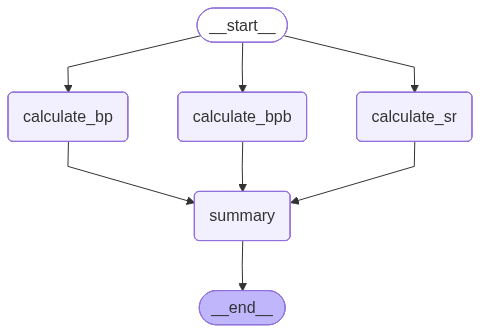

In [58]:
graph= StateGraph(Match_State)

graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bp', calculate_bp)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('summary', summary)

graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bp')
graph.add_edge(START, 'calculate_bpb')

graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_bp', 'summary')
graph.add_edge('calculate_bpb', 'summary')

graph.add_edge('summary', END)

workflow= graph.compile()
workflow

In [59]:
initial_state= {
    'Balls': 10,
    'runs': 30,
    'fours': 2,
    'sixes': 3
}

final_state= workflow.invoke(initial_state)

final_state

{'Balls': 10,
 'runs': 30,
 'fours': 2,
 'sixes': 3,
 'sr': 300.0,
 'bp': 86.66666666666667,
 'bpb': 2.0,
 'summary': '    Strike Rate= 300.0\n    Boundary Percentage= 86.66666666666667\n    Balls per Boundary= 2.0'}

In [60]:
print(final_state['summary'])

    Strike Rate= 300.0
    Boundary Percentage= 86.66666666666667
    Balls per Boundary= 2.0


# Essay Grading Workflow

In [62]:
model= ChatMistralAI(model='mistral-small-latest')

In [67]:
class EvaluationSchema(BaseModel):
    
    feedback: str= Field(description='Detailed feedback about the essay')
    score: int= Field(description='Score out of 10', ge=0, le=10)


In [68]:
structured_model= model.with_structured_output(EvaluationSchema)

In [86]:
essay= """ 
India is rapidly emerging as a global powerhouse in Artificial Intelligence, driven by a "AI for All" philosophy that emphasizes inclusive growth, with its AI market projected to triple to billion by 2027. Positioned among the top four countries in AI skills, India leverages a massive, cost-effective talent pool that accounts for 16% of global AI talent. The government is accelerating this growth through the IndiaAI Mission, a ₹10,371 crore initiative, which has significantly upgraded computing infrastructure to over 38,000 GPUs to foster AI research and development. Furthermore, India is uniquely positioning itself as a leader in responsible AI by embedding ethical practices into high-impact applications in agriculture, healthcare, and education. Through Digital Public Infrastructure (DPI) and AI integration, India is transitioning from a service provider to a global AI innovation hub that prioritizes social empowerment.
"""

In [71]:
prompt= f'Evaluate the language quality of the following essay and provide a feedback and assign score out of 10. \n {essay}'
result= structured_model.invoke(prompt)

In [75]:
print(result.feedback)

The essay is well-structured and informative, providing a clear overview of India's advancements in Artificial Intelligence. The language is generally clear and effective, with a formal tone suitable for the topic. However, there are a few areas for improvement:

1. **Grammar and Clarity**: 
   - The phrase 'projected to triple to billion by 2027' is grammatically incorrect and incomplete. It should be revised to 'projected to triple to USD 10 billion by 2027' or similar.
   - The sentence 'Positioned among the top four countries in AI skills, India leverages a massive, cost-effective talent pool that accounts for 16% of global AI talent.' is a bit long and could be split for better readability.

2. **Precision and Conciseness**:
   - The phrase 'a ₹10,371 crore initiative' is specific but could be followed by a brief explanation or conversion to a more internationally recognized format (e.g., approximately USD 1.25 billion) for a global audience.
   - The term 'Digital Public Infrastr

In [ ]:
result.score 

8

In [87]:
class EssayState(TypedDict):
    
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    
    individual_scores: Annotated[list[int], operator.add]
    average_score: float

In [88]:
def language_feedback(state: EssayState):
    
    prompt= f'Evaluate the language quality of the following essay and provide a feedback and assign score out of 10. \n {state['essay']}'
    output= structured_model.invoke(prompt)
    
    return {'language_feedback': output.feedback, 'individual_scores': [output.score]}

def analysis_feedback(state: EssayState):
    
    prompt= f'Evaluate the analysis quality of the following essay and provide a feedback and assign score out of 10. \n {state['essay']}'
    output= structured_model.invoke(prompt)
    
    return {'analysis_feedback': output.feedback, 'individual_scores': [output.score]}

def clarity_feedback(state: EssayState):
    
    prompt= f'Evaluate the clarity quality of the following essay and provide a feedback and assign score out of 10. \n {state['essay']}'
    output= structured_model.invoke(prompt)
    
    return {'clarity_feedback': output.feedback, 'individual_scores': [output.score]}

def overall_feedback(state: EssayState):
    
    prompt= f'Based on the following feedbacks create a summarized feedback \n language_feedback: {state["language_feedback"]} \n analysis_feedback: {state["analysis_feedback"]} \n clarity_feedback: {state["clarity_feedback"]}'
    overall_feedback= model.invoke(prompt).content
    
    avg_score= sum(state['individual_scores'])/len(state['individual_scores'])
    
    return {'overall_feedback': overall_feedback, 'average_score': avg_score}

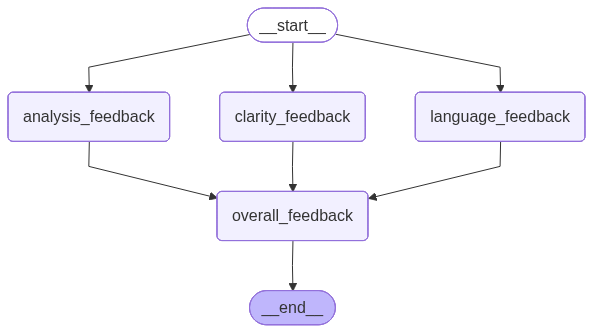

In [89]:
graph= StateGraph(EssayState)

graph.add_node('language_feedback', language_feedback)
graph.add_node('analysis_feedback', analysis_feedback)
graph.add_node('clarity_feedback', clarity_feedback)
graph.add_node('overall_feedback', overall_feedback)

graph.add_edge(START, 'language_feedback')  
graph.add_edge(START, 'analysis_feedback')
graph.add_edge(START, 'clarity_feedback')

graph.add_edge('language_feedback', 'overall_feedback')
graph.add_edge('analysis_feedback', 'overall_feedback')
graph.add_edge('clarity_feedback', 'overall_feedback')

graph.add_edge('overall_feedback', END)

workflow= graph.compile()
workflow

In [ ]:
# intentionally bad essay to test the workflow
essay2= """ 
US presidents are the guys who run America and make all the laws and stuff. The first one was George Washington who had wooden teeth which is gross, but he was a good general and won the war against the British people. Abraham Lincoln was also a president and he freed all the slaves in a huge battle, which is why he is on the five-dollar bill. Some presidents are bad like Nixon who got caught stealing stuff from a hotel or something and had to quit. It is not really a fun job because you have to make hard choices all day and everyone yells at you, plus you might get shot, which happened to Kennedy in Texas. They live in the White House, which is in DC, and they get to ride in a big plane called Air Force One and meet other kings. Basically, you have to be super smart or maybe lucky to be president, but it is just a job at the end of the day.
"""

In [92]:
initial_state= {
    'essay': essay2
}

final_state= workflow.invoke(initial_state)

final_state

{'essay': ' \nUS presidents are the guys who run America and make all the laws and stuff. The first one was George Washington who had wooden teeth which is gross, but he was a good general and won the war against the British people. Abraham Lincoln was also a president and he freed all the slaves in a huge battle, which is why he is on the five-dollar bill. Some presidents are bad like Nixon who got caught stealing stuff from a hotel or something and had to quit. It is not really a fun job because you have to make hard choices all day and everyone yells at you, plus you might get shot, which happened to Kennedy in Texas. They live in the White House, which is in DC, and they get to ride in a big plane called Air Force One and meet other kings. Basically, you have to be super smart or maybe lucky to be president, but it is just a job at the end of the day.\n',
 'language_feedback': "The essay provides a basic overview of the role of US presidents and mentions a few historical figures, b